# 00 - Data Preprocessing

**Project:** WiFi CSI Indoor Presence Detection  
**Hardware:** ESP32 collecting Channel State Information at ~80 rows/s  
**Goal:** Convert raw per-session CSVs into a single clean feature matrix ready for all modeling notebooks.

## What this notebook does

1. **Explore** — scan the raw CSVs, count rows per session and class
2. **Load & clean** — concatenate sessions, standardise the label column, drop inactive subcarriers
3. **Feature engineering** — add four scalar summary features per row
4. **Sanity check** — visualise amplitude distributions and class balance
5. **Investigate** — examine an unexpected low-amplitude cluster in the data
6. **Row-rate verification** — confirm ~80 rows/s against timestamps; `processed.csv` is saved inline after § 5

## Why we drop certain subcarriers

The ESP32 reports 64 raw amplitude columns (`amp_0` … `amp_63`).  
Indices 0, 1, 27–36, and 63 are guard or pilot subcarriers they carry no data
and their amplitudes are unreliable. Keeping them would inject noise into every
model. We retain **51 active subcarriers**.

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re



# --- Raw data location ------------------------------------------------------
RAW_DIR       = "../data/full-study/raw"
PROCESSED_DIR = "../data/full-study/processed"
PROCESSED_CSV = os.path.join(PROCESSED_DIR, "processed.csv")

# --- Plot output ------------------------------------------------------------
SAVE_DIR = "full-study-outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Subcarrier filtering ---------------------------------------------------
DROP_IDX  = [0, 1] + list(range(27, 37)) + [63]          # guard + pilot
AMP_COLS  = [f"amp_{i}" for i in range(64)]               # all 64 raw columns
KEEP_COLS = [f"amp_{i}" for i in range(64) if i not in DROP_IDX]  # 51 active

# --- Scalar features added in feature engineering ---------------------------
SCALAR_COLS = ["csi_mean", "csi_std", "csi_max", "csi_energy"]

print(f"Keep cols : {len(KEEP_COLS)} active subcarriers")
print(f"Drop cols : {len(DROP_IDX)} (guard/pilot)")

Keep cols : 51 active subcarriers
Drop cols : 13 (guard/pilot)


## 1 - Explore raw files

Before loading anything, we scan the raw directory to confirm which sessions
exist, how many rows each contains, and what the class balance looks like per session.

In [3]:
csv_files = sorted(glob.glob(os.path.join(RAW_DIR, "**/*.csv"), recursive=True))
print(f"Found {len(csv_files)} CSV files\n")

rows = []
for path in csv_files:
    df_tmp = pd.read_csv(path, usecols=["label"])
    session = os.path.splitext(os.path.basename(path))[0]
    counts  = df_tmp["label"].value_counts().to_dict()
    total   = len(df_tmp)
    rows.append({"session": session, "total": total, **counts})
    print(f"  {session:<40}  {total:>6} rows  {counts}")

summary = pd.DataFrame(rows)
print(f"\nTotal rows : {summary['total'].sum():,}")

Found 11 CSV files

  01_day_session1_night_empty                25297 rows  {'empty': 25297}
  01_day_session2_night_empty                25431 rows  {'empty': 25431}
  01_day_session3_night_occupied             39620 rows  {'exist': 39620}
  01_day_session4_night_occupied             30741 rows  {'exist': 30741}
  02_day_session1_morning_empty              35077 rows  {'empty': 35077}
  02_day_session2_morning_empty              27590 rows  {'empty': 27590}
  02_day_session3_morning_empty              25409 rows  {'empty': 25409}
  02_day_session4_morning_empty              25365 rows  {'empty': 25365}
  02_day_session5_morning_empty              25765 rows  {'empty': 25765}
  02_day_session6_morning_occupied           57834 rows  {'exist': 57834}
  02_day_session7_morning_occupied           58386 rows  {'exist': 58386}

Total rows : 376,515


## 2 - Load & clean

11 sessions 376,515 rows total. Two things to fix before we go further:

- The occupied class label is `exist` in the raw files we rename it to `occupied`
  for clarity throughout the project.
- We drop the 13 guard/pilot subcarrier columns, only the 51 active ones are kept.

Session names are derived from file names and stored in a `session` column so that
downstream notebooks can split train/test by session without rereading filenames.

In [4]:
frames = []
for path in csv_files:
    df_tmp          = pd.read_csv(path)
    df_tmp["session"] = os.path.splitext(os.path.basename(path))[0]
    frames.append(df_tmp)

data = pd.concat(frames, ignore_index=True)

# Standardise label
data["label"] = data["label"].replace({"exist": "occupied"})

# Drop guard/pilot subcarrier columns
data = data.drop(columns=[c for c in AMP_COLS if c not in KEEP_COLS])

print(f"Shape after load & clean : {data.shape}")
print(f"\nLabel distribution:")
print(data["label"].value_counts())
print(f"\nSessions ({data['session'].nunique()}):")
print(data["session"].unique())

Shape after load & clean : (376515, 56)

Label distribution:
label
empty       189934
occupied    186581
Name: count, dtype: int64

Sessions (11):
<StringArray>
[     '01_day_session1_night_empty',      '01_day_session2_night_empty',
   '01_day_session3_night_occupied',   '01_day_session4_night_occupied',
    '02_day_session1_morning_empty',    '02_day_session2_morning_empty',
    '02_day_session3_morning_empty',    '02_day_session4_morning_empty',
    '02_day_session5_morning_empty', '02_day_session6_morning_occupied',
 '02_day_session7_morning_occupied']
Length: 11, dtype: str


## 3 - Feature engineering

Each row currently has 51 amplitude values. We compress them into four scalar
summaries that give models a compact global view of the channel state per measurement:

| Feature | Formula | Intuition |
|---|---|---|
| `csi_mean` | mean of 51 amps | average signal level |
| `csi_std` | std of 51 amps | spectral spread / multipath richness |
| `csi_max` | max of 51 amps | peak subcarrier energy |
| `csi_energy` | sum amp^2 | total received power |

We also extract a `day` column from the session name (`01_day` => night, `02_day` => morning)
for later analysis.

In [5]:
# Day label (night = day 1, morning = day 2)
data["day"] = data["session"].str.extract(r"^(0[12]_day)")[0]

# Four scalar CSI features
data["csi_mean"]   = data[KEEP_COLS].mean(axis=1)
data["csi_std"]    = data[KEEP_COLS].std(axis=1)
data["csi_max"]    = data[KEEP_COLS].max(axis=1)
data["csi_energy"] = (data[KEEP_COLS] ** 2).sum(axis=1)

print(f"Shape after feature engineering : {data.shape}")
print(f"\nNew scalar features, summary statistics:")
print(data[SCALAR_COLS].describe().round(3))

Shape after feature engineering : (376515, 61)

New scalar features, summary statistics:
         csi_mean     csi_std     csi_max  csi_energy
count  376515.000  376515.000  376515.000  376515.000
mean       18.928       6.415      29.405   21435.394
std         4.055       2.312       7.437    7791.308
min         6.159       1.815       9.220    2281.981
25%        17.902       4.854      26.926   19526.065
50%        20.420       6.058      30.594   23679.932
75%        21.602       8.353      34.438   26288.209
max        57.537      28.016     105.081  207033.377


## 4 - Sanity check, visualisation

Before saving we verify two things visually:

1. **Amplitude distributions by class** do empty and occupied rows look different
   in the scalar features? If the sensor is capturing presence, we expect at least
   some separation in mean or energy.
2. **Per session row counts** confirms no session is unexpectedly tiny or dominant.

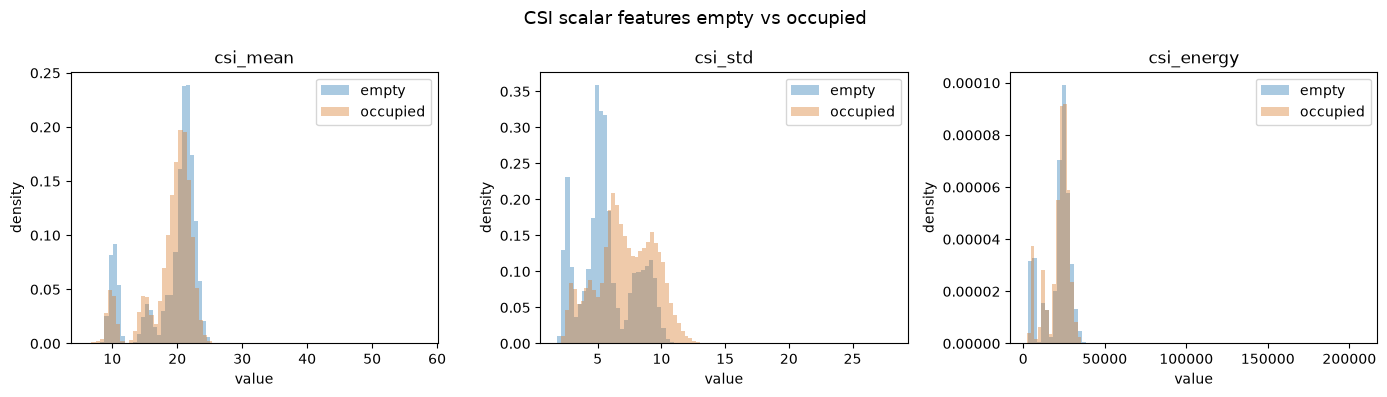


Rows per session:
session
01_day_session1_night_empty         25297
01_day_session2_night_empty         25431
01_day_session3_night_occupied      39620
01_day_session4_night_occupied      30741
02_day_session1_morning_empty       35077
02_day_session2_morning_empty       27590
02_day_session3_morning_empty       25409
02_day_session4_morning_empty       25365
02_day_session5_morning_empty       25765
02_day_session6_morning_occupied    57834
02_day_session7_morning_occupied    58386


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("CSI scalar features empty vs occupied", fontsize=13)

for ax, col in zip(axes, ["csi_mean", "csi_std", "csi_energy"]):
    for label, color in [("empty", "#2C7BB6"), ("occupied", "#D97B2B")]:
        vals = data.loc[data["label"] == label, col]
        ax.hist(vals, bins=80, alpha=0.40, color=color, label=label, density=True)
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/00_csi_scalar_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-session counts
print("\nRows per session:")
print(data.groupby("session")["label"].count().to_string())

### Visual Analysis

`csi_mean` shows the clearest separation: the empty distribution peaks tightly
around 20 while occupied spreads a heavier tail toward lower values (~10–15),
indicating a human body consistently attenuates the mean signal amplitude.

`csi_std` shows visible class separation occupied rooms
produce a much broader, flatter spread (up to ~25) versus the sharp empty peak
at ~4. Multipath scattering from a moving or stationary person introduces
variance that an empty room simply does not generate.

`csi_energy` mirrors mean closely and adds little independent
information, but the overlap is tighter here both classes concentrate below
50 000, so energy alone would be a weak standalone feature.

**Takeaway:** standard deviation is the most discriminative scalar feature.
The distributions overlap substantially, which explains why single feature
classifiers fail and why windowed aggregation (mean + std across 55 subcarriers)
is essential to push F1 above 0.9

## 5 - Low amplitude cluster investigation

The `csi_mean` histogram shows a secondary peak near 8–10 that exists almost
exclusively in the **empty** class. Before treating this as noise or corruption,
we need to understand where it comes from.

**Hypothesis:** the ESP32 channel baseline differs between night (day 1) and
morning (day 2) recordings perhaps due to temperature, interference, or
automatic gain control. If so both classes should be affected proportionally
within each day, and no single session should be corrupted.

In [7]:
THRESHOLD = 12   # csi_mean below this defines the "low" cluster

low  = data[data["csi_mean"] < THRESHOLD]
high = data[data["csi_mean"] >= THRESHOLD]

print(f"Rows with csi_mean < {THRESHOLD} : {len(low):,}  ({100*len(low)/len(data):.1f}%)")
print(f"Rows with csi_mean ≥ {THRESHOLD} : {len(high):,}  ({100*len(high)/len(data):.1f}%)\n")

print("Low cluster breakdown by day and label:")
print(low.groupby(["day", "label"]).size().to_string())

print("\nLow cluster breakdown by session:")
print(low.groupby("session").size().sort_values(ascending=False).to_string())

Rows with csi_mean < 12 : 48,977  (13.0%)
Rows with csi_mean ≥ 12 : 327,538  (87.0%)

Low cluster breakdown by day and label:
day     label   
01_day  empty           8
        occupied      352
02_day  empty       31055
        occupied    17562

Low cluster breakdown by session:
session
02_day_session6_morning_occupied    9087
02_day_session7_morning_occupied    8475
02_day_session1_morning_empty       8387
02_day_session3_morning_empty       6994
02_day_session2_morning_empty       6503
02_day_session5_morning_empty       4926
02_day_session4_morning_empty       4245
01_day_session3_night_occupied       268
01_day_session4_night_occupied        84
01_day_session2_night_empty            6
01_day_session1_night_empty            2


In [8]:
# Drop the single row with NaN amplitude values (hardware measurement dropout)
nan_rows = data[data[KEEP_COLS].isna().any(axis=1)]
print(f"Rows with NaN amplitudes : {len(nan_rows)}")
if len(nan_rows):
    print(nan_rows[["session", "label"] + KEEP_COLS[:5]])

data = data.dropna(subset=KEEP_COLS).reset_index(drop=True)
print(f"Shape after NaN drop     : {data.shape}")

Rows with NaN amplitudes : 1
                              session  label  amp_2   amp_3   amp_4  amp_5  \
259816  02_day_session5_morning_empty  empty   32.0  30.067  27.166  28.16   

         amp_6  
259816  27.019  
Shape after NaN drop     : (376514, 61)


### Finding: channel baseline shift, not corruption

The low amplitude cluster is concentrated in **day 2 (morning)** and spans
**both classes**:

- Morning empty:    31,055 low rows  
- Morning occupied: 17,562 low rows  
- Night sessions:      360 low rows (negligible)

Crucially, the effect is not class specific the channel is simply quieter
overall during some morning recordings, likely due to environmental conditions
(temperature, interference, automatic gain control drift). Both empty and
occupied sessions are affected proportionally.

**Decision: keep all rows.**  
Dropping these rows would discard real measurements and introduce a subtle
selection bias. The models must learn to detect occupancy under varying
channel conditions that is a realistic requirement. If we cleaned this away,
we would be overfitting to a single channel state and reporting inflated results.

This is the only data cleaning step that removes rows all other preprocessing
(label rename, column drop, feature engineering) is lossless.

In [9]:
os.makedirs(PROCESSED_DIR, exist_ok=True)
data.to_csv(PROCESSED_CSV, index=False)

## 6 - Row rate verification

The ESP32 is documented as collecting at ~80 rows/s. We verify this against
the `time` column (Unix timestamps in seconds) to confirm the sampling rate
is consistent across sessions.

In [10]:
print("Approximate row rate per session (rows / elapsed seconds):\n")

for sess, grp in data.groupby("session"):
    t       = pd.to_datetime(grp["time"], errors="coerce").sort_values()
    elapsed = (t.iloc[-1] - t.iloc[0]).total_seconds()
    rate    = len(grp) / elapsed if elapsed > 0 else float("nan")
    print(f"  {sess:<45}  {rate:6.1f} rows/s")

Approximate row rate per session (rows / elapsed seconds):

  01_day_session1_night_empty                      80.9 rows/s
  01_day_session2_night_empty                      81.3 rows/s
  01_day_session3_night_occupied                   64.5 rows/s
  01_day_session4_night_occupied                   49.4 rows/s
  02_day_session1_morning_empty                    90.9 rows/s
  02_day_session2_morning_empty                    88.3 rows/s
  02_day_session3_morning_empty                    81.6 rows/s
  02_day_session4_morning_empty                    81.5 rows/s
  02_day_session5_morning_empty                    82.4 rows/s
  02_day_session6_morning_occupied                 81.4 rows/s
  02_day_session7_morning_occupied                 83.4 rows/s


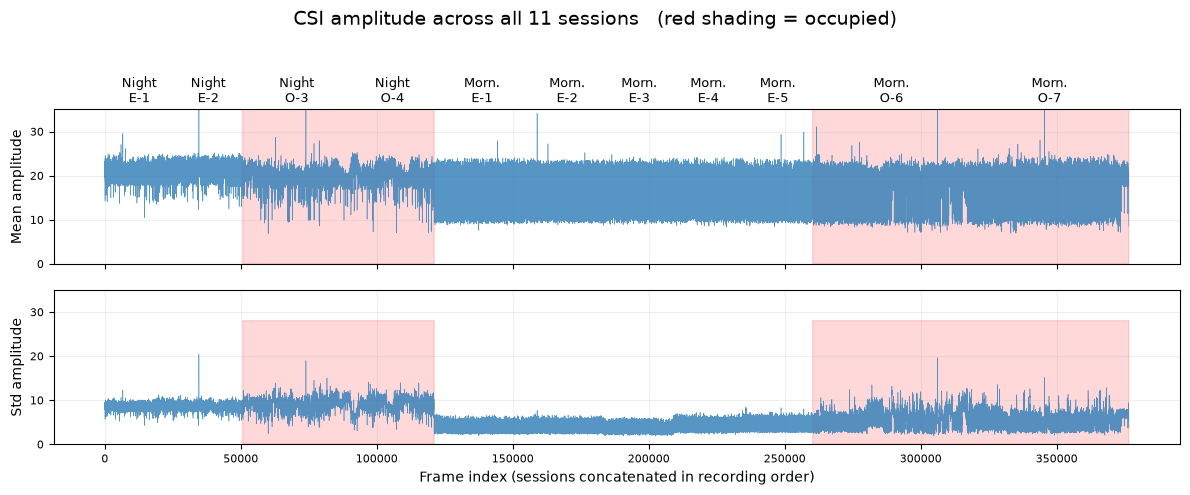

In [16]:
# CSI signal overview across all sessions 
# -- text sizes ------
FS_TITLE   = 14
FS_LABEL   = 10
FS_TICK    = 8
FS_SESSION = 9

# ── line / shading ───────────────────────────
LW         = 0.4       # signal line width
ALPHA_LINE = 0.8       # signal line opacity
ALPHA_FILL = 0.15      # occupied shading opacity
COLOR_LINE = "#2C7BB6"
COLOR_OCC  = "red"
STEP       = 10        # downsample every N frames

# ── figure ───────────────────────────────────
FW, FH     = 12, 5

# ─────────────────────────────────────────────

seen, session_names_ordered = set(), []
for s in data["session"]:
    if s not in seen:
        seen.add(s)
        session_names_ordered.append(s)

def get_short(sess_name):
    n   = sess_name.lower()
    day = "Night" if "night" in n else "Morn."
    occ = "O" if "occupied" in n else "E"
    num = (re.findall(r"\d+", sess_name) or ["?"])[-1]
    return f"{day}\n{occ}-{num}"

chunks, session_meta, offset = [], [], 0
for sess in session_names_ordered:
    grp = data[data["session"] == sess].reset_index(drop=True)
    if grp.empty:
        continue
    chunks.append(grp)
    session_meta.append((offset, offset + len(grp) - 1, get_short(sess)))
    offset += len(grp)

concat = pd.concat(chunks, ignore_index=True)
concat["csi_mean"] = concat[KEEP_COLS].mean(axis=1)
concat["csi_std"]  = concat[KEEP_COLS].std(axis=1)

x   = np.arange(len(concat))
occ = (concat["label"].values == "occupied")

fig, axes = plt.subplots(2, 1, figsize=(FW, FH), sharex=True)
fig.suptitle(
    "CSI amplitude across all 11 sessions   (red shading = occupied)",
    fontsize=FS_TITLE
)

for ax, col, ylabel in zip(
    axes,
    ["csi_mean", "csi_std"],
    ["Mean amplitude", "Std amplitude"],
):
    ymin, ymax = float(concat[col].min()), float(concat[col].max())
    ax.plot(x[::STEP], concat[col].values[::STEP], lw=LW, alpha=ALPHA_LINE, color=COLOR_LINE)
    ax.fill_between(x, 0, ymax, where=occ, alpha=ALPHA_FILL, color=COLOR_OCC, zorder=0)
    ax.set_ylabel(ylabel, fontsize=FS_LABEL)
    ax.set_ylim(0, 35) # ax.set_ylim(ymin, ymax) 
    ax.tick_params(axis='both', labelsize=FS_TICK)
    ax.grid(True, alpha=0.2)

for start, end, short in session_meta:
    mid = (start + end) / 2
    axes[0].text(mid, 1.02, short, ha="center", va="bottom",
                 fontsize=FS_SESSION,
                 transform=axes[0].get_xaxis_transform())

axes[1].set_xlabel(
    "Frame index (sessions concatenated in recording order)",
    fontsize=FS_LABEL
)

fig.tight_layout(rect=[0, 0, 1, 0.95]) # red_
plt.savefig(f"{SAVE_DIR}/00_full_temporal_signal.png", dpi=150, bbox_inches="tight")
plt.show()

### Visual Analysis

Red bands = room occupied (Night O-3, Night O-4, Morn. O-6, Morn. O-7)

The most striking feature is not occupied vs empty it is the **baseline shift between
recording days**. Night sessions (frames 0–120k) sit at a mean amplitude of ~20–25
morning sessions (frames 120k–376k) drop to ~12–15 and stay there. This is
cross session RF drift: temperature, interference, or the ESP32's automatic gain
control shifts the channel baseline overnight, independent of room occupancy.

The std panel tells the same story with more contrast. Night sessions show a broad,
noisy spread (~8–10) morning sessions compress into a tight band (~4–6). Occupied
sessions push std upward multipath scattering from a human body adds spectral
variance but the effect is partially hidden inside the day to day drift.

**Takeaway:** a model trained only on night data and tested on morning data faces a
distribution shift of the same magnitude as the empty vs occupied signal itself.
This is why per session train/test splits are essential and why cross session
generalisation is the core challenge of the study.

### Summary

Most sessions land within 80–91 rows/s consistent with the ESP32 spec.

The two night occupied sessions (`session3`: 64.5, `session4`: 49.4) run slower,
likely due to brief pauses or longer recording gaps during the night collection.
This doesn't affect the model windows are constructed per session from contiguous
rows, so variable collection speed only changes how many seconds a window spans,
not the feature values within it.